<a href="https://colab.research.google.com/github/spentapa3-lgtm/deeplearning-/blob/main/Regularized_deep_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.2934 - val_loss: 0.1969
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.1825 - val_loss: 0.1705
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.1662 - val_loss: 0.1606
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.1598 - val_loss: 0.1565
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - loss: 0.1567 - val_loss: 0.1540
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.1547 - val_loss: 0.1525
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.1535 - val_loss: 0.1517
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.1527 - val_loss: 0.1507
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.1519 - val_loss: 0.1503
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.1516 - val_loss: 0.1499
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.151

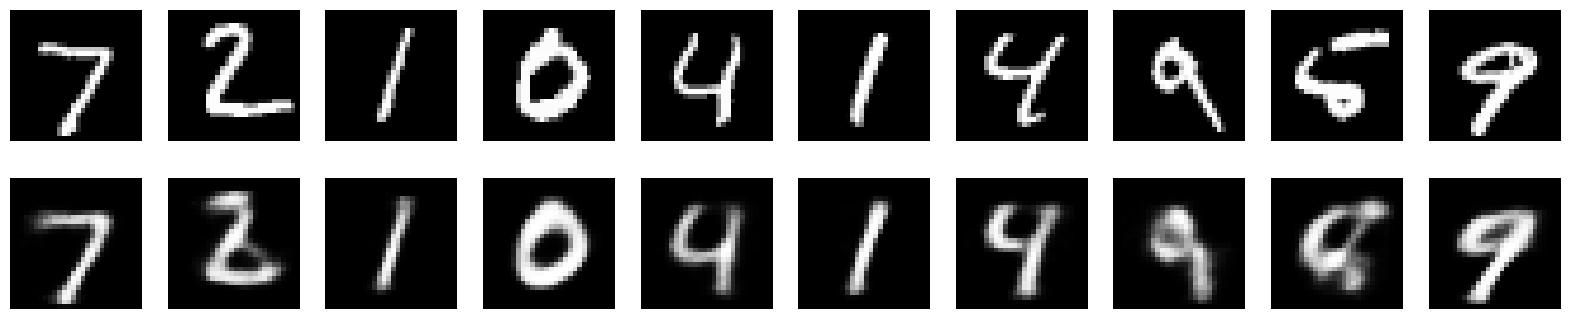

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

input_dim = 784
encoding_dim1 = 512
encoding_dim2 = 256
encoding_dim3 = 128
reg_factor = 1e-4

input_img = keras.Input(shape=(input_dim,))

encoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(input_img)

encoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

encoded = layers.Dense(
    encoding_dim3,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

decoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

decoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

decoded = layers.Dense(
    input_dim,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

autoencoder = keras.Model(inputs=input_img, outputs=decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()